In [26]:
from datasets import load_dataset
import pandas as pd
from IPython.display import display

In [27]:
from itertools import islice
import re
import numpy as np

ds_stream = load_dataset(
    "wikimedia/wikipedia", "20231101.en", split="train", streaming=True
)
df = pd.DataFrame(list(islice(ds_stream, 1000)))
df = df[["text"]].copy()
df["text"] = df["text"].fillna("")

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

In [28]:
df

,text
0,Anarchism is a political philosophy and moveme...
1,Albedo (; ) is the fraction of sunlight that i...
2,"A, or a, is the first letter and the first vow..."
3,Alabama () is a state in the Southeastern regi...
4,"In Greek mythology, Achilles ( ) or Achilleus ..."
...,...
995,Action Against Hunger () is a global humanitar...
996,"A&W, AW, Aw, aW or aw may refer to:\n\nCompani..."
997,Apoptosis (from ) is a form of programmed cell...
998,"Appomattox, shorthand for the surrender of Rob..."


In [29]:
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use("seaborn-v0_8")

token_pattern = re.compile(r"\b\w+\b")
def average_word_length(text: str) -> float:
    tokens = token_pattern.findall(text.lower())
    return float(np.mean([len(token) for token in tokens])) if tokens else 0.0

def lexical_diversity(text: str) -> float:
    tokens = token_pattern.findall(text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["sentence_count"] = df["text"].str.count(r"[.!?]")
df["avg_word_length"] = df["text"].apply(average_word_length)

char_nonzero = df["char_count"].replace(0, np.nan)
sentence_nonzero = df["sentence_count"].replace(0, np.nan)

# Derive additional lexical and punctuation-based features
df["digit_count"] = df["text"].str.count(r"\d")
df["uppercase_count"] = df["text"].str.count(r"[A-Z]")
df["punctuation_count"] = df["text"].str.count(r"[^\w\s]")
df["unique_word_ratio"] = df["text"].apply(lexical_diversity)
df["punctuation_density"] = (df["punctuation_count"] / char_nonzero).fillna(0.0)
df["uppercase_ratio"] = (df["uppercase_count"] / char_nonzero).fillna(0.0)
df["chars_per_sentence"] = (df["char_count"] / sentence_nonzero).fillna(df["char_count"])
df["words_per_sentence"] = (df["word_count"] / sentence_nonzero).fillna(df["word_count"])
df["digit_density"] = (df["digit_count"] / df["word_count"].replace(0, np.nan)).fillna(0.0)

metrics_basic = ["char_count", "word_count", "sentence_count", "avg_word_length"]
metrics_extended = [
    "unique_word_ratio","punctuation_density","uppercase_ratio",
    "chars_per_sentence","words_per_sentence","digit_count","digit_density"
 ]
df_summary = df[metrics_basic].describe().round(2)
df_extended_summary = df[metrics_extended].describe().round(3)
display(df_summary, df_extended_summary)

,char_count,word_count,sentence_count,avg_word_length
count,1000.00,1000.00,1000.00,1000.00
mean,23085.97,3635.86,181.48,5.06
std,21897.73,3449.03,174.07,0.32
min,117.00,17.00,0.00,4.00
25%,6261.25,989.50,47.00,4.85
50%,16746.00,2734.00,128.50,5.02
75%,32298.50,5052.00,269.25,5.24
max,120422.00,19388.00,1286.00,6.55


,unique_word_ratio,punctuation_density,uppercase_ratio,chars_per_sentence,words_per_sentence,digit_count,digit_density
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.378,0.033,0.041,179.106,27.452,443.431,0.133
std,0.120,0.012,0.018,220.409,31.067,641.094,0.162
min,0.156,0.007,0.010,44.569,6.931,0.000,0.000
25%,0.284,0.025,0.029,117.156,18.570,61.750,0.042
50%,0.361,0.029,0.039,133.014,21.032,184.500,0.083
75%,0.444,0.035,0.050,151.845,24.000,524.500,0.144
max,0.812,0.089,0.143,2682.500,421.000,5352.000,1.176


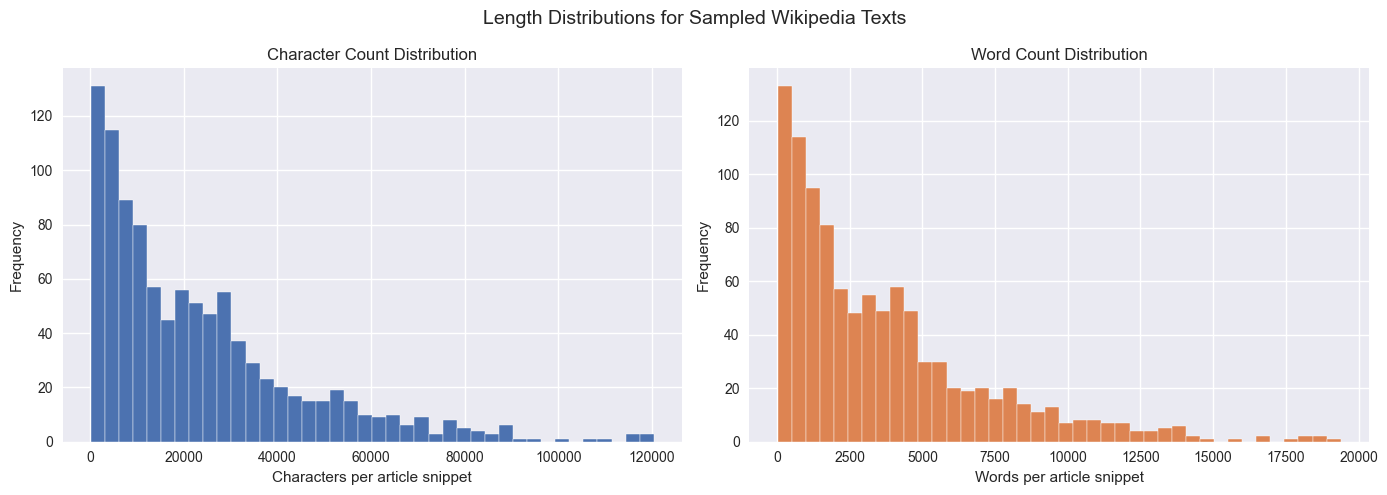

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["char_count"], bins=40, color="#4c72b0", edgecolor="white")
axes[0].set_title("Character Count Distribution")
axes[0].set_xlabel("Characters per article snippet")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["word_count"], bins=40, color="#dd8452", edgecolor="white")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words per article snippet")
axes[1].set_ylabel("Frequency")

plt.suptitle("Length Distributions for Sampled Wikipedia Texts", fontsize=14)
plt.tight_layout()
plt.show()

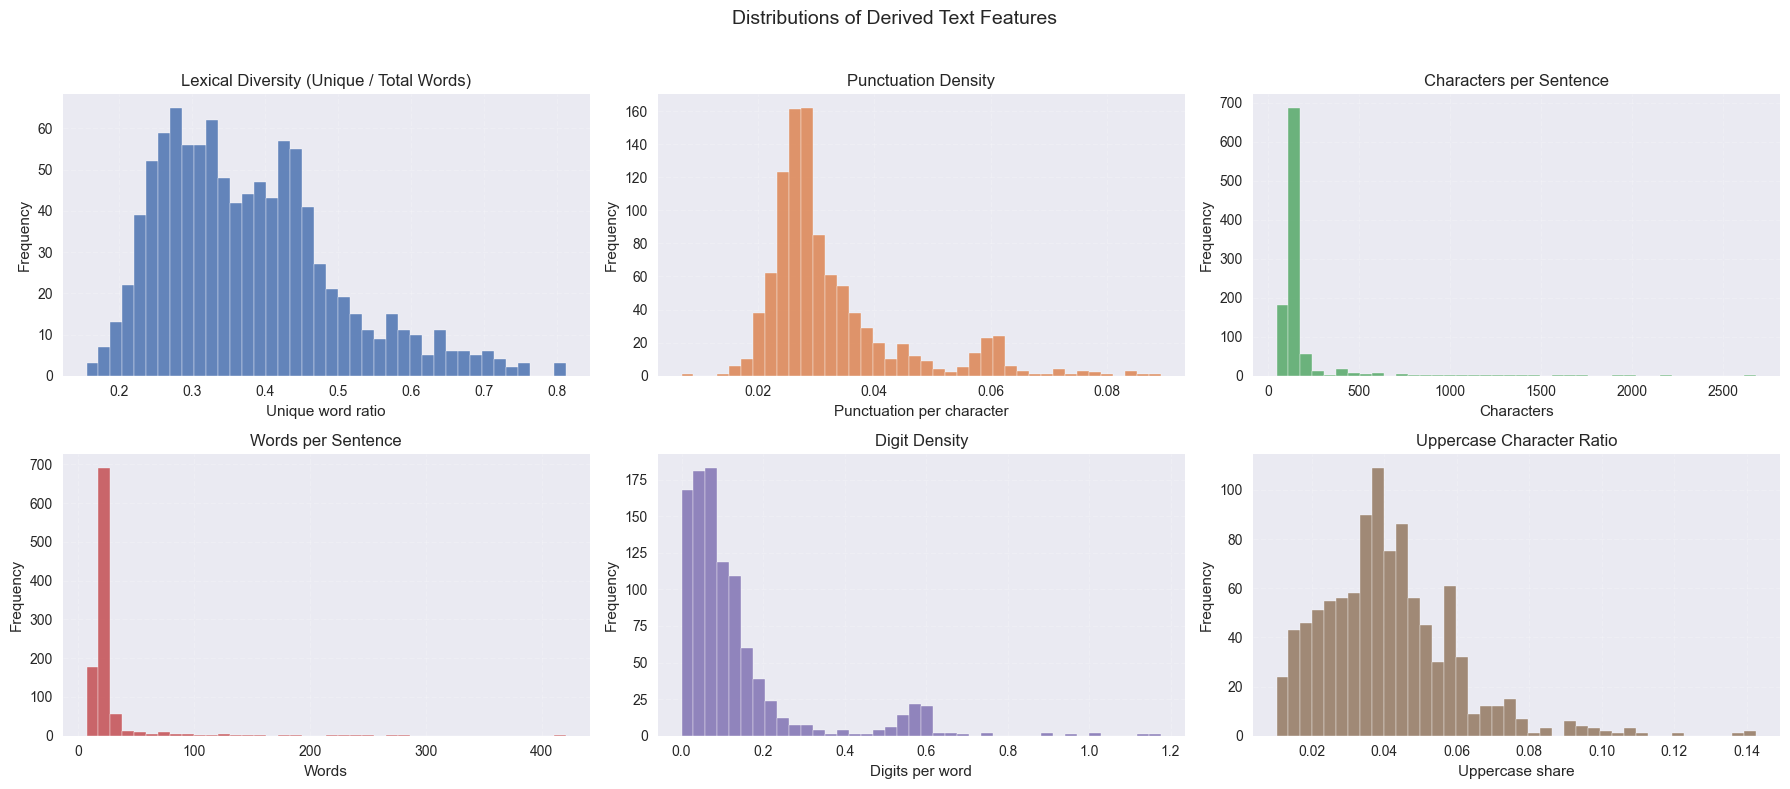

In [31]:
feature_specs = [
    ("unique_word_ratio", "Lexical Diversity (Unique / Total Words)", "Unique word ratio"),
    ("punctuation_density", "Punctuation Density", "Punctuation per character"),
    ("chars_per_sentence", "Characters per Sentence", "Characters"),
    ("words_per_sentence", "Words per Sentence", "Words"),
    ("digit_density", "Digit Density", "Digits per word"),
    ("uppercase_ratio", "Uppercase Character Ratio", "Uppercase share")
]
feature_colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (col, title, xlabel), color in zip(axes.flat, feature_specs, feature_colors):
    ax.hist(df[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.2)

plt.suptitle("Distributions of Derived Text Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

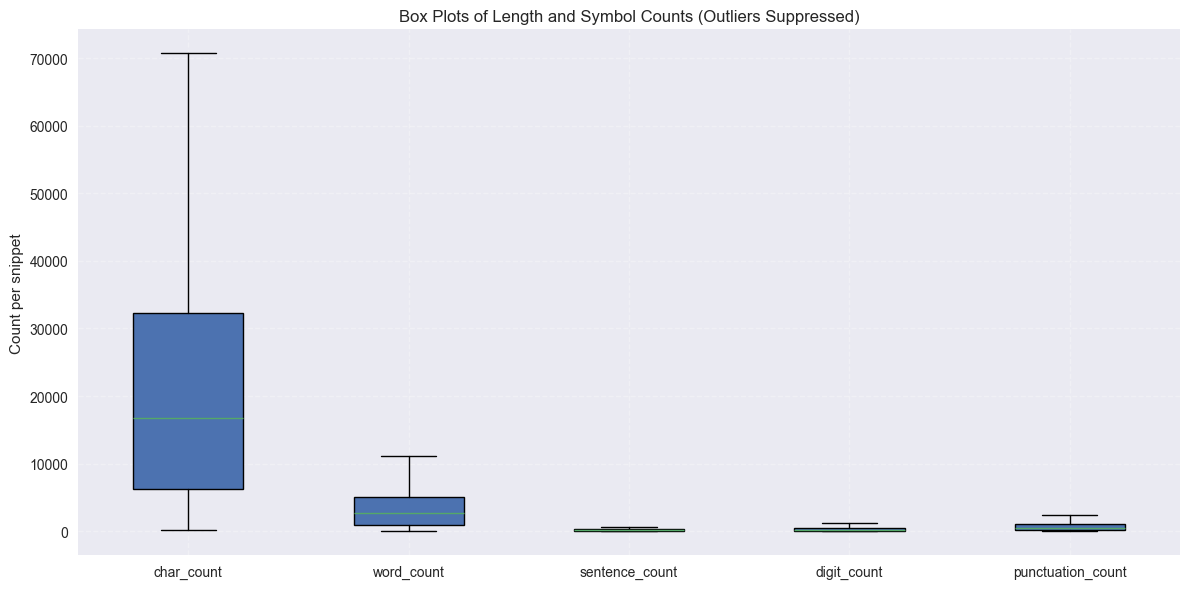

In [32]:
boxplot_columns = ["char_count", "word_count", "sentence_count", "digit_count", "punctuation_count"]
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([df[col] for col in boxplot_columns], labels=boxplot_columns, showfliers=False, patch_artist=True)
for patch, color in zip(ax.artists, ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#937860"]):
    patch.set_facecolor(color)
ax.set_title("Box Plots of Length and Symbol Counts (Outliers Suppressed)")
ax.set_ylabel("Count per snippet")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

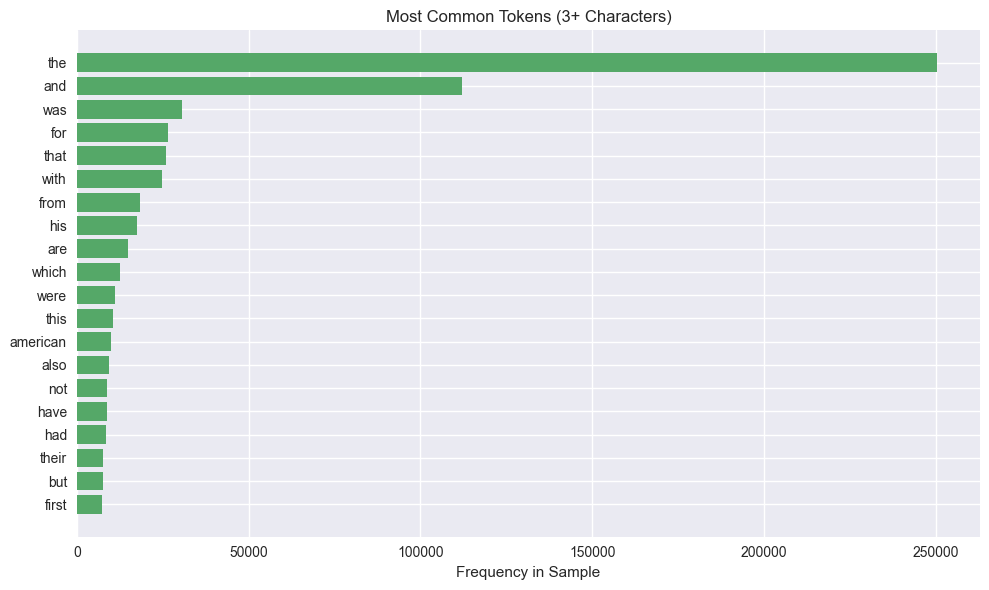

,token,count
0,the,250329
1,and,112192
2,was,30748
3,for,26667
4,that,25925
5,with,24691
6,from,18379
7,his,17540
8,are,14938
9,which,12542


In [33]:
freq_pattern = re.compile(r"\b[a-z]{3,}\b")
token_counts = Counter()
for text in df["text"]:
    token_counts.update(freq_pattern.findall(text.lower()))

top_tokens = token_counts.most_common(20)
top_tokens_df = pd.DataFrame(top_tokens, columns=["token", "count"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_tokens_df["token"][::-1], top_tokens_df["count"][::-1], color="#55a868")
ax.set_title("Most Common Tokens (3+ Characters)")
ax.set_xlabel("Frequency in Sample")
plt.tight_layout()
plt.show()

top_tokens_df

In [34]:
avg_char_count = df_summary.loc["mean", "char_count"]
median_word_count = df_summary.loc["50%", "word_count"]
avg_word_length = df_summary.loc["mean", "avg_word_length"]
sentences_per_snippet = df_summary.loc["mean", "sentence_count"]
lexical_diversity = df_extended_summary.loc["mean", "unique_word_ratio"]
punctuation_density = df_extended_summary.loc["mean", "punctuation_density"]
chars_per_sentence = df_extended_summary.loc["mean", "chars_per_sentence"]
words_per_sentence = df_extended_summary.loc["mean", "words_per_sentence"]
digit_density = df_extended_summary.loc["mean", "digit_density"]
uppercase_ratio = df_extended_summary.loc["mean", "uppercase_ratio"]
median_digit_count = df_extended_summary.loc["50%", "digit_count"]
top_tokens_preview = ", ".join(token for token, _ in top_tokens[:5])

print(f"Average snippet length: {avg_char_count:.0f} characters")
print(f"Median snippet length: {median_word_count:.0f} words")
print(f"Mean word length: {avg_word_length:.2f} characters")
print(f"Mean sentences per snippet: {sentences_per_snippet:.2f}")
print(f"Mean lexical diversity: {lexical_diversity:.2f} unique/total words")
print(f"Average punctuation density: {punctuation_density:.2f} per character")
print(f"Mean chars per sentence: {chars_per_sentence:.0f}; words per sentence: {words_per_sentence:.1f}")
print(f"Digit density: {digit_density:.2f} numeric tokens per word (median count {median_digit_count:.0f})")
print(f"Uppercase ratio: {uppercase_ratio:.2f} of characters")
print(f"Frequent content words: {top_tokens_preview}")

Average snippet length: 23086 characters
Median snippet length: 2734 words
Mean word length: 5.06 characters
Mean sentences per snippet: 181.48
Mean lexical diversity: 0.38 unique/total words
Average punctuation density: 0.03 per character
Mean chars per sentence: 179; words per sentence: 27.5
Digit density: 0.13 numeric tokens per word (median count 184)
Uppercase ratio: 0.04 of characters
Frequent content words: the, and, was, for, that


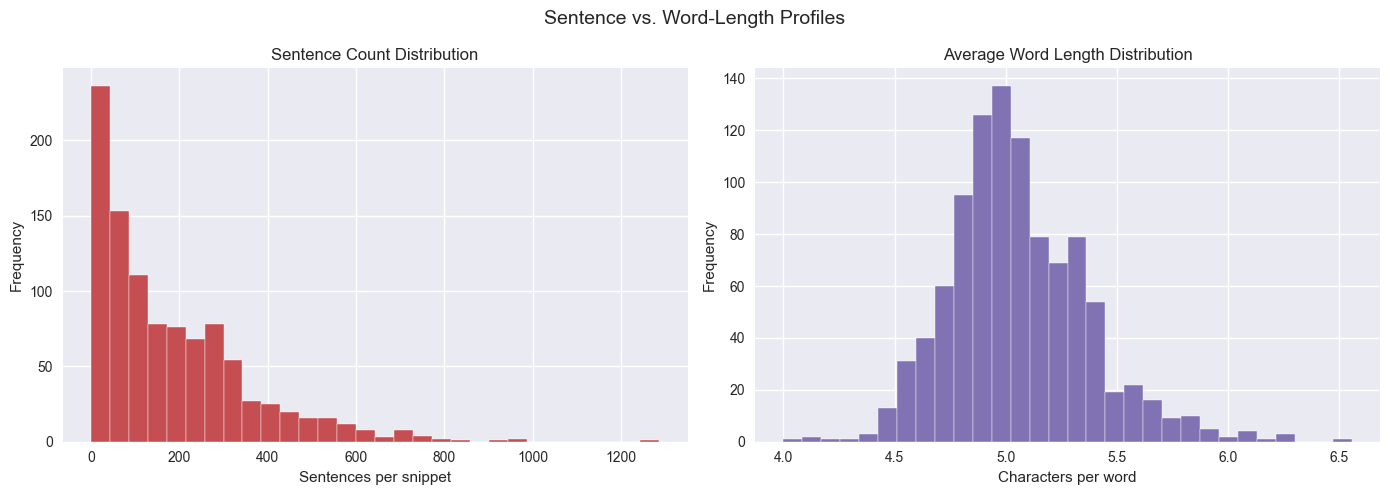

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["sentence_count"], bins=30, color="#c44e52", edgecolor="white")
axes[0].set_title("Sentence Count Distribution")
axes[0].set_xlabel("Sentences per snippet")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["avg_word_length"], bins=30, color="#8172b3", edgecolor="white")
axes[1].set_title("Average Word Length Distribution")
axes[1].set_xlabel("Characters per word")
axes[1].set_ylabel("Frequency")

plt.suptitle("Sentence vs. Word-Length Profiles", fontsize=14)
plt.tight_layout()
plt.show()

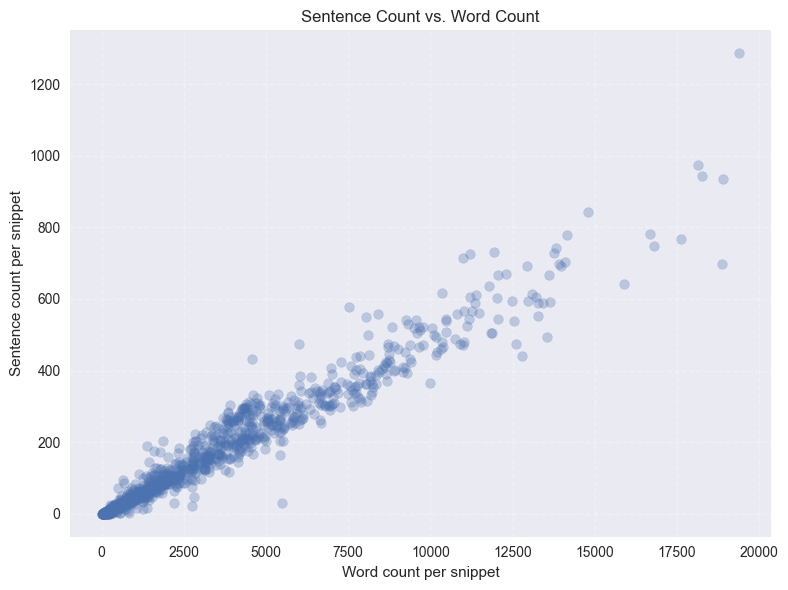

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["word_count"], df["sentence_count"], alpha=0.3, color="#4c72b0")
ax.set_title("Sentence Count vs. Word Count")
ax.set_xlabel("Word count per snippet")
ax.set_ylabel("Sentence count per snippet")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

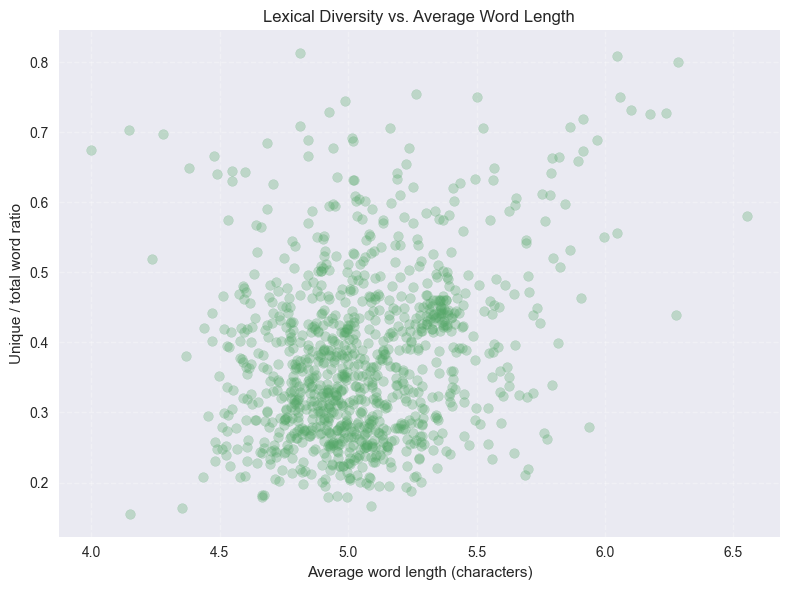

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["avg_word_length"], df["unique_word_ratio"], alpha=0.3, color="#55a868")
ax.set_title("Lexical Diversity vs. Average Word Length")
ax.set_xlabel("Average word length (characters)")
ax.set_ylabel("Unique / total word ratio")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

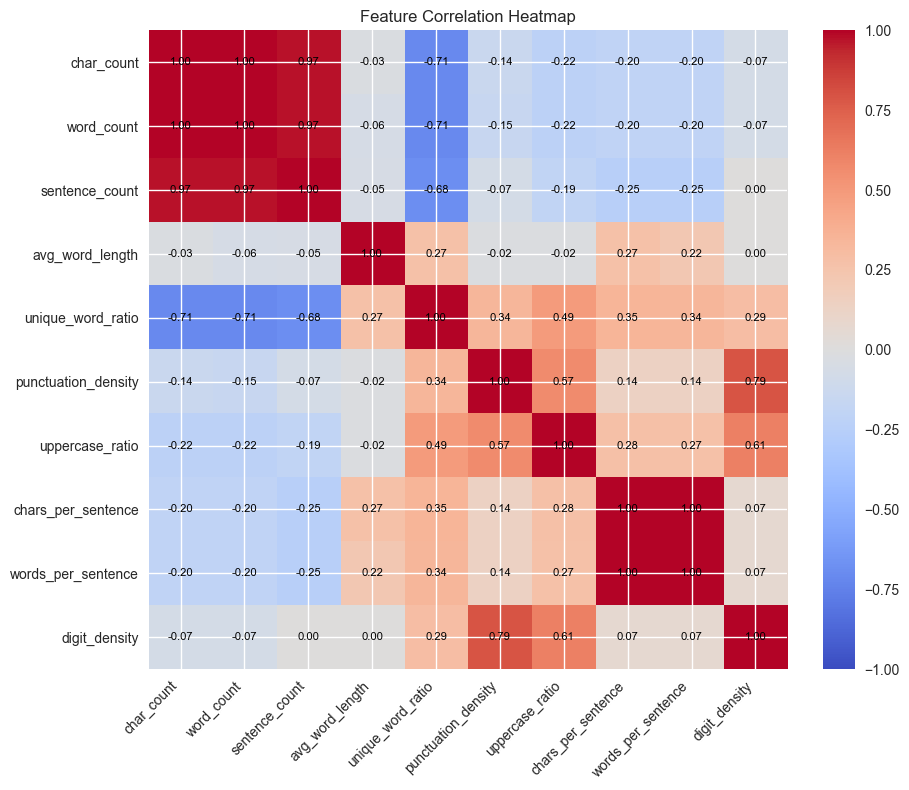

,char_count,word_count,sentence_count,avg_word_length,unique_word_ratio,punctuation_density,uppercase_ratio,chars_per_sentence,words_per_sentence,digit_density
char_count,1.00,1.00,0.97,-0.03,-0.71,-0.14,-0.22,-0.20,-0.20,-0.07
word_count,1.00,1.00,0.97,-0.06,-0.71,-0.15,-0.22,-0.20,-0.20,-0.07
sentence_count,0.97,0.97,1.00,-0.05,-0.68,-0.07,-0.19,-0.25,-0.25,0.00
avg_word_length,-0.03,-0.06,-0.05,1.00,0.27,-0.02,-0.02,0.27,0.22,0.00
unique_word_ratio,-0.71,-0.71,-0.68,0.27,1.00,0.34,0.49,0.35,0.34,0.29
punctuation_density,-0.14,-0.15,-0.07,-0.02,0.34,1.00,0.57,0.14,0.14,0.79
uppercase_ratio,-0.22,-0.22,-0.19,-0.02,0.49,0.57,1.00,0.28,0.27,0.61
chars_per_sentence,-0.20,-0.20,-0.25,0.27,0.35,0.14,0.28,1.00,1.00,0.07
words_per_sentence,-0.20,-0.20,-0.25,0.22,0.34,0.14,0.27,1.00,1.00,0.07
digit_density,-0.07,-0.07,0.00,0.00,0.29,0.79,0.61,0.07,0.07,1.00


In [38]:
corr_columns = [
    "char_count","word_count","sentence_count","avg_word_length",
    "unique_word_ratio","punctuation_density","uppercase_ratio",
    "chars_per_sentence","words_per_sentence","digit_density"
]
corr_matrix = df[corr_columns].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr_columns)))
ax.set_yticklabels(corr_columns)

for (i, j), value in np.ndenumerate(corr_matrix.values):
    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=8)

ax.set_title("Feature Correlation Heatmap")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr_matrix

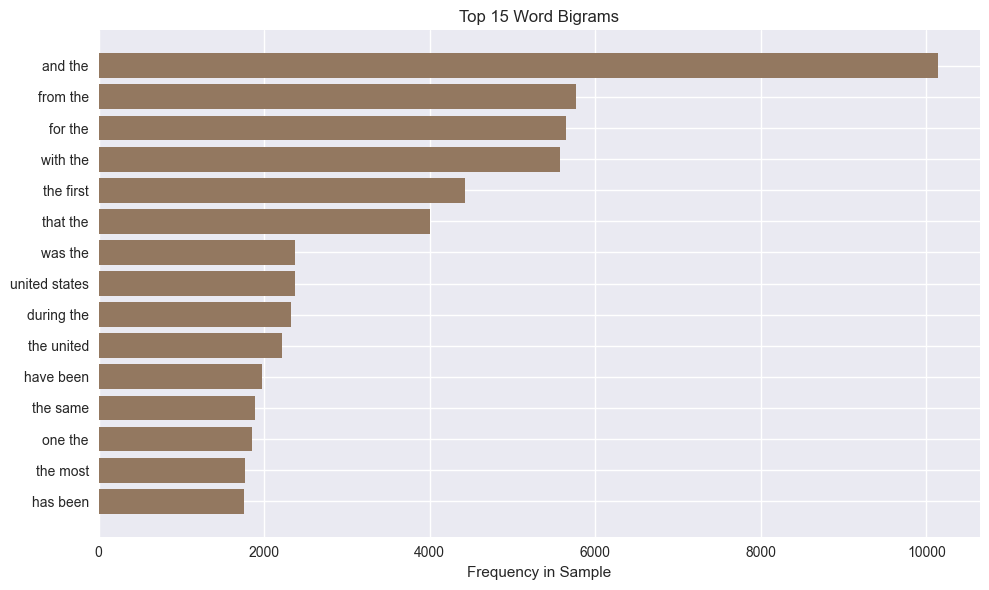

,bigram,count
0,and the,10140
1,from the,5766
2,for the,5651
3,with the,5568
4,the first,4431
5,that the,4005
6,was the,2376
7,united states,2369
8,during the,2321
9,the united,2212


In [39]:
bigram_counts = Counter()
for text in df["text"]:
    tokens = freq_pattern.findall(text.lower())
    bigram_counts.update(zip(tokens, tokens[1:]))
top_bigrams = bigram_counts.most_common(15)
top_bigrams_df = pd.DataFrame(
    {
        "bigram": [" ".join(bigram) for bigram, _ in top_bigrams],
        "count": [count for _, count in top_bigrams]
    }
 )
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_bigrams_df["bigram"][::-1], top_bigrams_df["count"][::-1], color="#937860")
ax.set_title("Top 15 Word Bigrams")
ax.set_xlabel("Frequency in Sample")
plt.tight_layout()
plt.show()

top_bigrams_df

### Exploratory Observations
- Cell 4 provides paired basic and extended summaries—scan the mean vs. median gaps to understand skew in counts and lexical ratios.
- Cells 5 and 6 chart raw length vs. derived feature distributions, highlighting long tails, punctuation-heavy snippets, and uppercase-heavy articles.
- Cell 7’s box plots make dispersion and potential outliers obvious across length and symbol counts without distraction from extreme values.
- Cells 8 and 14 cover token-level structure: unigram vs. bigram bars expose topical vocabulary and collocations in the slice.
- Cells 10 through 13 capture structural relationships—compare scatterplots with the heatmap to confirm linear trends and spot anomalies.